# 3) Exploring the Data

## EDA

In [6]:
# Loaded all the libraries because I'll be using a whole lot

# Core Libraries
import warnings
import os
import glob
import joblib

import numpy as np
import pandas as pd
from scipy.stats.mstats import winsorize

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.spatial.distance import cosine

warnings.filterwarnings("ignore")

# Clean plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Optional display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Scikit-Learn: Model Selection / Validation
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)

# Scikit-Learn: Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Scikit-Learn: Regression Models
from sklearn.linear_model import LinearRegression

# Scikit-Learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import Lasso

# Scikit-Learn: Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier,
)

from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import PercentFormatter

# Scikit-Learn: Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.metrics.pairwise import cosine_similarity

# Gradient Boosting Libraries
import xgboost as xgb
import lightgbm as lgb

# Interpretability
import shap

# Association Rules
from mlxtend.frequent_patterns import apriori, association_rules


print("✅ Libraries loaded!")

# Define random state
RANDOM_STATE = 51

✅ Libraries loaded!


In [7]:
# Import the main dataframe
df = pd.read_csv('df.csv')

display(df.head(10))
display(df.sample(10))
display(df.describe(include='all'))
display(df.info())
display(df.shape)

,Unnamed: 0,index,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charg

,Unnamed: 0,index,ticker,fiscal_year,fiscal_period,period_end_date,inc_currency,inc_revenue,inc_revenue_product,inc_revenue_services,inc_cost_of_revenue,inc_gross_profit,inc_operating_expenses,inc_research_development,inc_selling_general_administrative,inc_selling_marketing_expenses,inc_general_admin_expenses,inc_depreciation_amortization,inc_depreciation,inc_amortization_of_intangibles,inc_stock_based_compensation,inc_operating_income,inc_interest_expense,inc_interest_income,inc_other_income_expense,inc_income_before_taxes,inc_income_tax_expense,inc_net_income_continuing_operations,inc_net_income_discontinued_operations,inc_net_income,inc_basic_shares_outstanding,inc_diluted_shares_outstanding,inc_weighted_average_basic_shares,inc_weighted_average_diluted_shares,inc_basic_eps,inc_diluted_eps,inc_dividends_per_share,inc_comprehensive_income,inc_other_comprehensive_income,inc_impairment_charges,inc_restructuring_costs,inc_net_income_noncontrolling_interest,inc_preferred_dividends,inc_net_income_available_to_common,inc_revenue_from_contracts_excluding_tax,inc_revenue_from_contracts_including_tax,inc_income_before_taxes_and_extraordinary,inc_other_comprehensive_income_net_of_tax,inc_comprehensive_income_net_of_tax,inc_interest_income_operating,api_ticker_used,bal_currency,bal_total_assets,bal_current_assets,bal_non_current_assets,bal_cash_and_equivalents,bal_short_term_investments,bal_long_term_investments,bal_accounts_receivable,bal_inventory,bal_property_plant_equipment,bal_goodwill,bal_intangible_assets,bal_other_current_assets,bal_other_non_current_assets,bal_prepaid_expenses,bal_total_liabilities,bal_current_liabilities,bal_non_current_liabilities,bal_accounts_payable,bal_accruals_current,bal_short_term_debt,bal_deferred_revenue_current,bal_other_current_liabilities,bal_long_term_debt,bal_deferred_tax_liabilities,bal_deferred_revenue_non_current,bal_other_non_current_liabilities,bal_accrued_liabilities,bal_total_equity,bal_retained_earnings,bal_additional_paid_in_capital,bal_treasury_stock,bal_treasury_shares,bal_accumulated_other_comprehensive_income,bal_noncontrolling_interest,bal_preferred_stock_value,bal_operating_lease_right_of_use_assets,bal_operating_lease_liability_current,bal_operating_lease_liability_noncurrent,bal_investment_securities_fair_value,bal_available_for_sale_debt_securities,bal_common_stock_shares_authorized,bal_shares_issued,bal_common_stock_par_value_per_share,bal_total_debt,bal_net_debt,bal_working_capital,bal_tangible_book_value,bal_book_value_per_share,cf_currency,cf_net_cash_from_operations,cf_deferred_taxes,cf_change_in_receivables,cf_change_in_inventory,cf_change_in_accounts_payable,cf_change_in_deferred_revenue,cf_other_operating_assets_change,cf_other_operating_liabilities_change,cf_tax_withholding_payments,cf_other_misc_operating,cf_net_cash_from_investing,cf_capital_expenditures,cf_acquisitions,cf_purchase_of_investments,cf_proceeds_from_investments,cf_recurring_capital_expenditures,cf_net_cash_from_financing,cf_issuance_of_debt,cf_repayment_of_debt,cf_repurchase_of_stock,cf_cash_at_beginning_of_period,cf_cash_at_end_of_period,cf_net_change_in_cash,cf_free_cash_flow,cf_levered_free_cash_flow,shr_basic_shares_outstanding,shr_diluted_shares_outstanding,shr_weighted_average_basic_shares,shr_weighted_average_diluted_shares,shr_treasury_shares,shr_dilution_percentage,shr_is_buyback,profile_api_ticker_used,sector,industry,company_name,fiscal_year_end,website_url,exchange,buyback_quarter,inc_net_interest_income,inc_provision_for_credit_losses,inc_net_interest_margin,inc_return_on_average_assets,inc_return_on_average_equity,inc_fee_income,inc_trading_revenue,inc_interest_income_loans_commercial,inc_interest_income_loans_consumer,inc_interest_income_loans_total,inc_interest_income_securities,inc_interest_expense_deposits,inc_interest_expense_borrowings,inc_interest_expense_long_term_debt,inc_net_interest_income_after_provision,inc_investment_banking_revenue,inc_asset_management_fees,inc_service_charg

Unnamed: 0         index ticker  fiscal_year fiscal_period period_end_date inc_currency   inc_revenue  \
count   17319.000000  17319.000000  17319  17319.00000         17319           17295        17281  1.706600e+04   
unique           NaN           NaN    954          NaN             4             493            1           NaN   
top              NaN           NaN      A          NaN            Q3      2023-09-30          USD           NaN   
freq             NaN           NaN     19          NaN          4587             741        17281           NaN   
mean     8659.000000   8659.000000    NaN   2022.95300           NaN             NaN          NaN  5.019603e+09   
std      4999.708992   4999.708992    NaN      1.37806           NaN             NaN          NaN  1.260546e+10   
min         0.000000      0.000000    NaN   2021.00000           NaN             NaN          NaN -3.791000e+09   
25%      4329.500000   4329.500000    NaN   2022.00000           NaN             NaN          NaN  5.367515e+08   
50%      8659.000000   8659.000000    NaN   2023.00000           NaN             NaN          NaN  1.550620e+09   
75%     12988.500000  12988.500000    NaN   2024.00000           NaN             NaN          NaN  4.082000e+09   
max     17318.000000  17318.000000    NaN   2025.00000           NaN             NaN          NaN  1.877920e+11   

        inc_revenue_product  inc_revenue_services  inc_cost_of_revenue  inc_gross_profit  inc_operating_expenses  \
count          7.123000e+03          6.358000e+03         1.395000e+04      1.394900e+04            1.405200e+04   
unique                  NaN                   NaN                  NaN               NaN                     NaN   
top                     NaN                   NaN                  NaN               NaN                     NaN   
freq                    NaN                   NaN                  NaN               NaN                     NaN   
mean           4.068554e+09          1.773594e+09         3.283636e+09      1.937814e+09            2.147962e+09   
std            1.092616e+10          6.382674e+09         8.977943e+09      5.864869e+09            6.634069e+09   
min           -1.019000e+09         -1.702000e+09        -5.852000e+09     -3.507000e+09           -1.378400e+10   
25%            2.178825e+08          4.317000e+07         2.175348e+08      2.405830e+08            2.088700e+08   
50%            1.028734e+09          2.490000e+08         7.782230e+08      5.970000e+08            5.879235e+08   
75%            3.504920e+09          1.100540e+09         2.533000e+09      1.404000e+09            1.771000e+09   
max            1.719140e+11          1.061110e+11         1.318250e+11      1.005950e+11            1.665890e+11   

        inc_research_development  inc_selling_general_administrative  inc_selling_marketing_expenses  \
count               6.554000e+03                        1.295700e+04                    3.977000e+03   
unique                       NaN                                 NaN                             NaN   
top                          NaN                                 NaN                             NaN   
freq                         NaN                                 NaN                             NaN   
mean                3.881814e+08                        7.045434e+08                    3.883715e+08   
std                 1.265532e+09                        1.783434e+09                    1.125249e+09   
min                -1.631000e+09                       -3.776000e+09                   -1.570000e+09   
25%                 2.913500e+07                        8.652000e+07                    3.950000e+07   
50%                 7.192300e+07                        2.448130e+08                    1.037000e+08   
75%                 2.363310e+08                        5.999100e+08                    2.360720e+08   
max                 1.515100e+10                        3.554000e+10                    1.31

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17319 entries, 0 to 17318
Columns: 768 entries, Unnamed: 0 to buyback_next_quarter
dtypes: float64(747), int64(5), object(16)
memory usage: 101.5+ MB


None

(17319, 768)

Buyback distribution:
Class 0: 9947 (57.4%)
Class 1: 7372 (42.6%)

Positive class rate: 42.6%


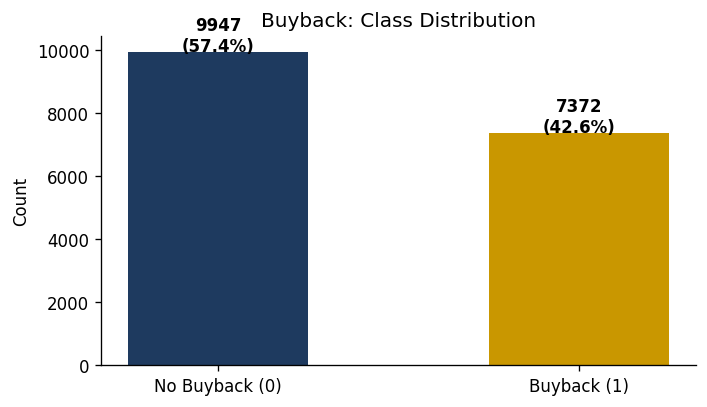

In [8]:
# Class distribution — important to check before modeling
buyback_counts = df['buyback_next_quarter'].value_counts().sort_index()
buyback_percents = buyback_counts / len(df)

print("Buyback distribution:")
for cls in buyback_counts.index:
    print(f"Class {cls}: {buyback_counts[cls]} ({buyback_percents[cls]:.1%})")

print(f"\nPositive class rate: {buyback_percents[1]:.1%}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(['No Buyback (0)', 'Buyback (1)'],
       buyback_counts.values,
       color=['#1E3A5F', '#C99700'],
       width=0.5)
ax.set_ylabel('Count')
ax.set_title('Buyback: Class Distribution')
for i, (count, pct) in enumerate(zip(buyback_counts.values, buyback_percents.values)):
    ax.text(i, count + 30, f"{count}\n({pct:.1%})", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Buyback percentage: 0.42566
No buyback percentage: 0.57434


,ticker,period_end_date,price_close_q,inc_diluted_eps,P/E_q
14649,STZ,2021-08-31,211.139999,0.01,21113.999939


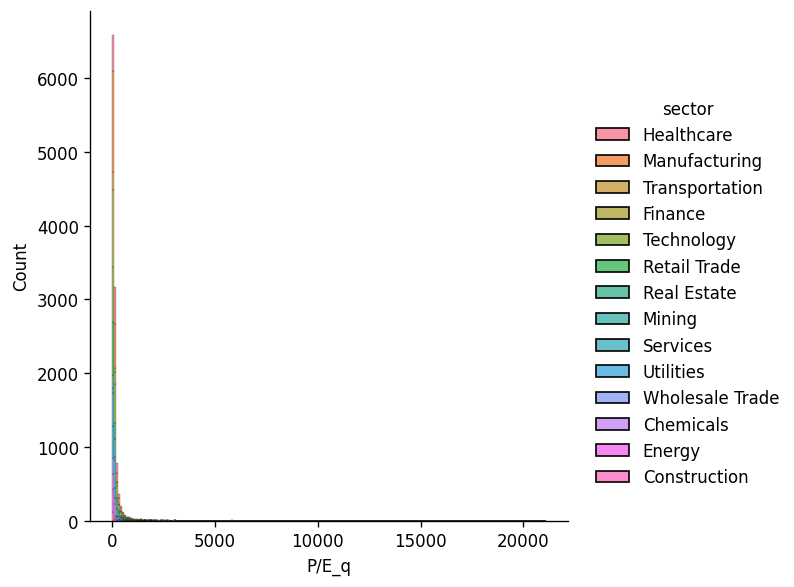

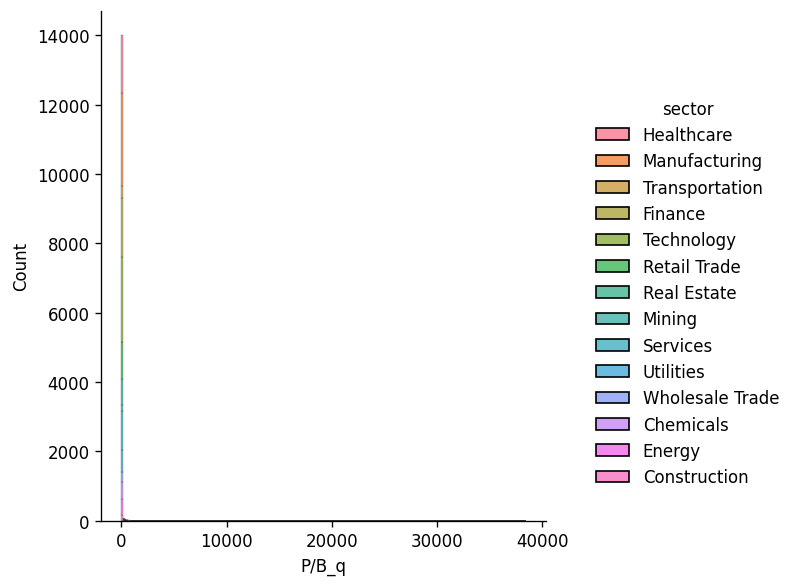

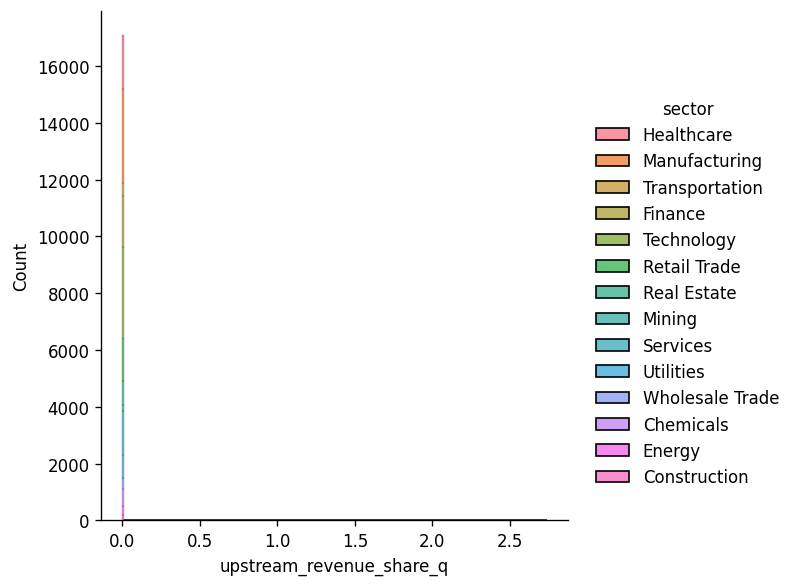

In [9]:
number_of_records = df.shape[0]

percent_of_buybacks_next_q = (df['buyback_next_quarter'] == 1).sum() / number_of_records
percent_of_no_buybacks_next_q = (df['buyback_next_quarter'] == 0).sum() / number_of_records

print(f"Buyback percentage: {percent_of_buybacks_next_q:.5f}")
print(f"No buyback percentage: {percent_of_no_buybacks_next_q:.5f}")

sns.displot(df, x="P/E_q", hue="sector", multiple="stack")
sns.displot(df, x="P/B_q", hue="sector", multiple="stack")
sns.displot(df, x="upstream_revenue_share_q", hue="sector", multiple="stack") # Hugly skewed. Need winsorization/log1 transformation

df.loc[df['P/E_q'] > 20000, ['ticker', 'period_end_date', 'price_close_q', 'inc_diluted_eps', 'P/E_q']].head(20) # Evidence of much needed Winsorization

# Here, we have major red flags from the dataset. Most features are right skewed due to unstable ratios denominaots, such as P/E_q due to a tiny inc_diluted_eps.
# Likewise with P/B, etc.

In [10]:
# Drop these columns (not predictive/weird)
df = df.drop(columns=['api_ticker_used', 'profile_api_ticker_used', 'sic_code', 'company_name', 'fiscal_year_end', 
                                'exchange', 'price_ticker_yf', 'price_date', 'industry', 'ticker'], errors='ignore')

# Drop these weird columns from forming
df.drop(columns=['Unnamed: 0', 'Index'], inplace=True, errors='ignore')

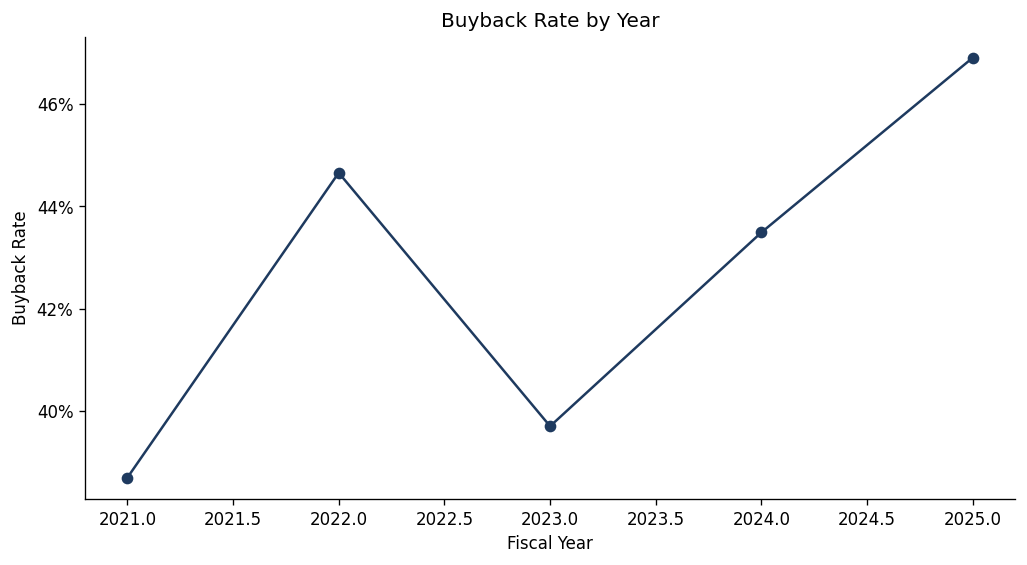

In [11]:
year_rates = df.groupby("fiscal_year")["buyback_next_quarter"].mean()

year_rates.plot(kind="line", marker="o", figsize=(10, 5), color = '#1E3A5F')
plt.title("Buyback Rate by Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Buyback Rate")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
plt.show()

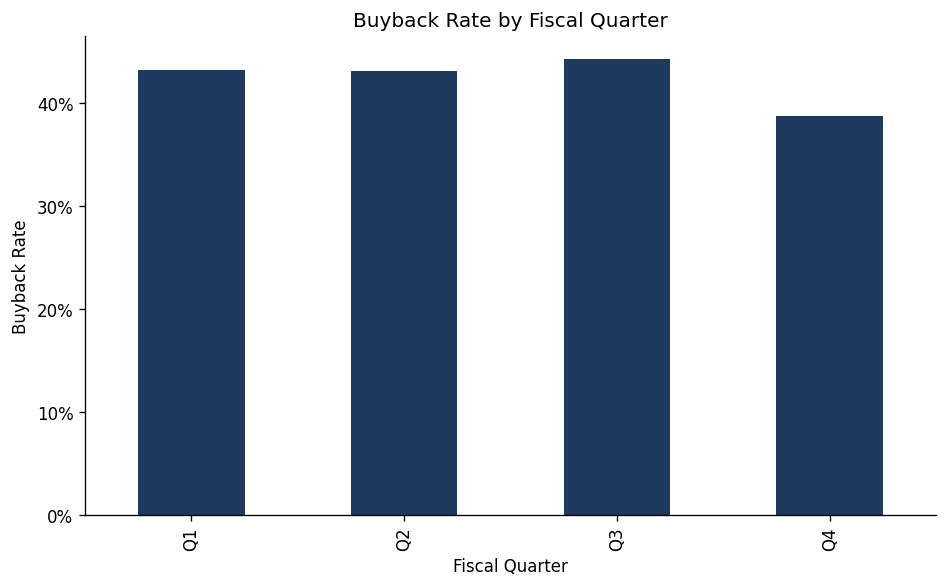

In [12]:
quarter_rates = (df.groupby("fiscal_period")["buyback_next_quarter"].mean().reindex(["Q1", "Q2", "Q3", "Q4"])
)

ax = quarter_rates.plot(kind="bar", figsize=(8, 5), color="#1E3A5F")

plt.title("Buyback Rate by Fiscal Quarter")
plt.xlabel("Fiscal Quarter")
plt.ylabel("Buyback Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

plt.tight_layout()
plt.show()

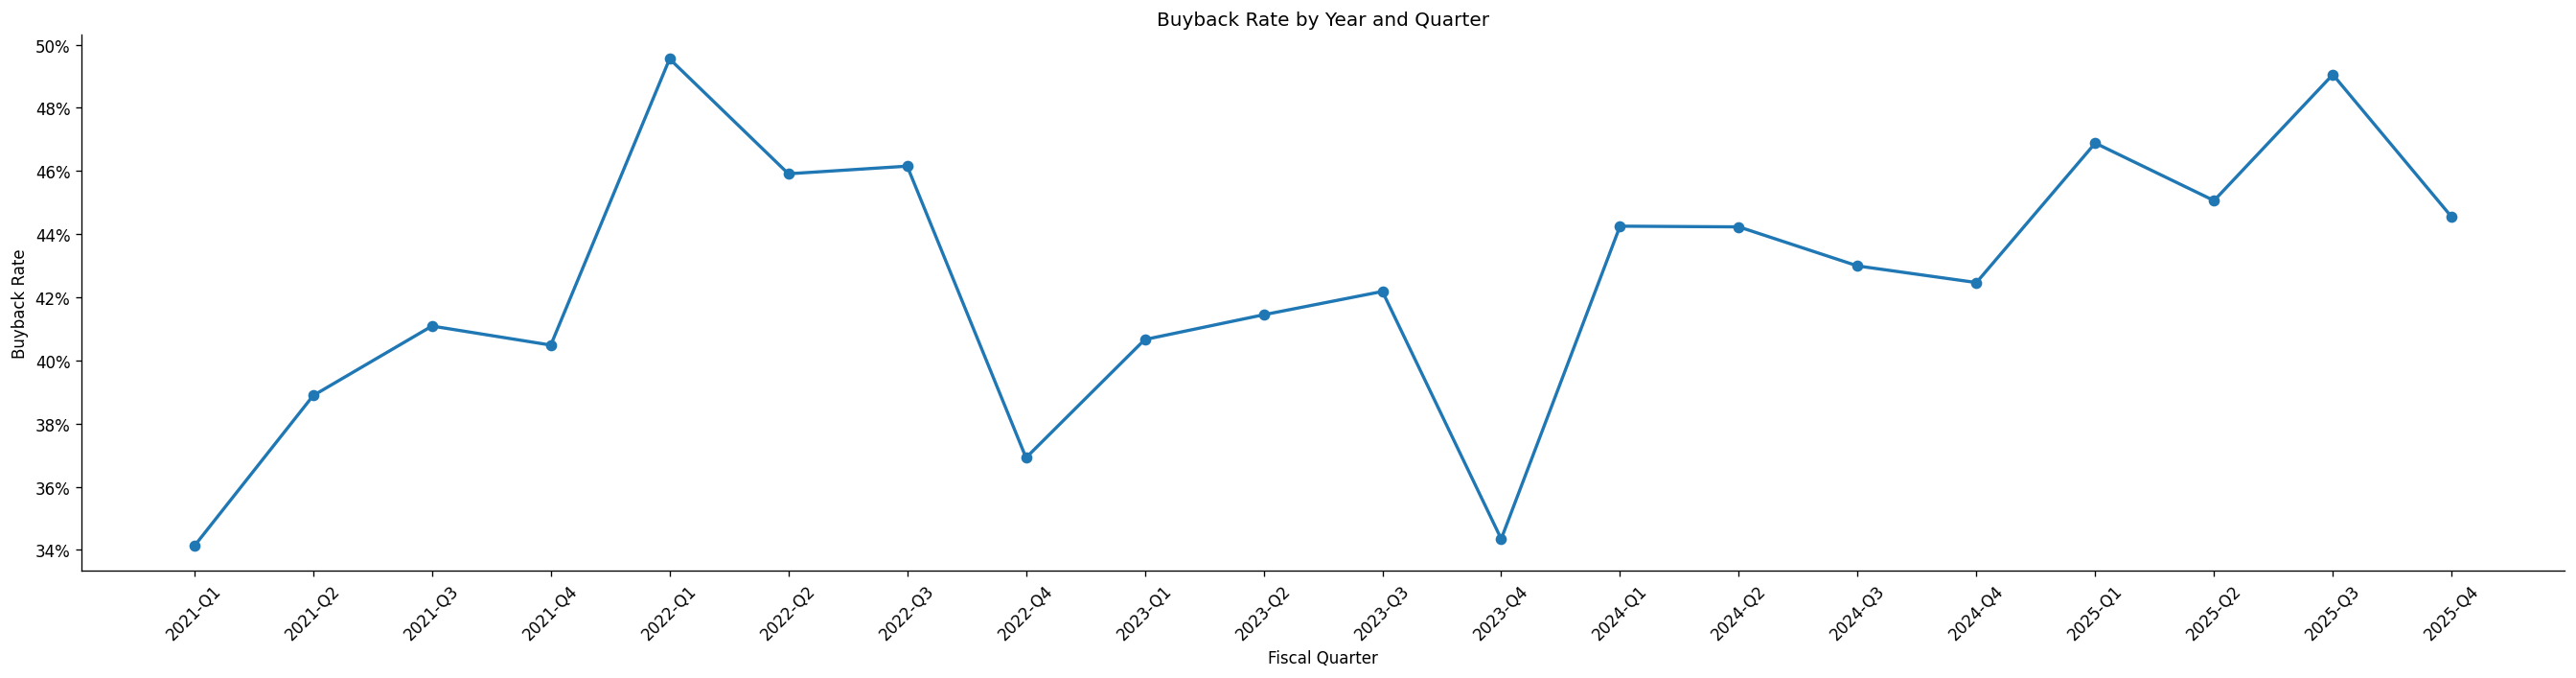

In [13]:
# Keep needed columns
time_rates = df[["fiscal_year", "fiscal_period", "buyback_next_quarter"]].dropna().copy()

# Make quarter sortable
time_rates["quarter_num"] = time_rates["fiscal_period"].str.extract("(\d)").astype(int)

# Average buyback rate by year-quarter
time_rates = (
    time_rates.groupby(["fiscal_year", "fiscal_period", "quarter_num"])["buyback_next_quarter"]
    .mean()
    .reset_index()
    .sort_values(["fiscal_year", "quarter_num"])
)

# Create combined label
time_rates["year_quarter"] = (
    time_rates["fiscal_year"].astype(str) + "-" + time_rates["fiscal_period"]
)

# Plot
plt.figure(figsize=(22.5, 6))
plt.plot(time_rates["year_quarter"], time_rates["buyback_next_quarter"], marker="o", linewidth=2)

plt.title("Buyback Rate by Year and Quarter")
plt.xlabel("Fiscal Quarter")
plt.ylabel("Buyback Rate")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

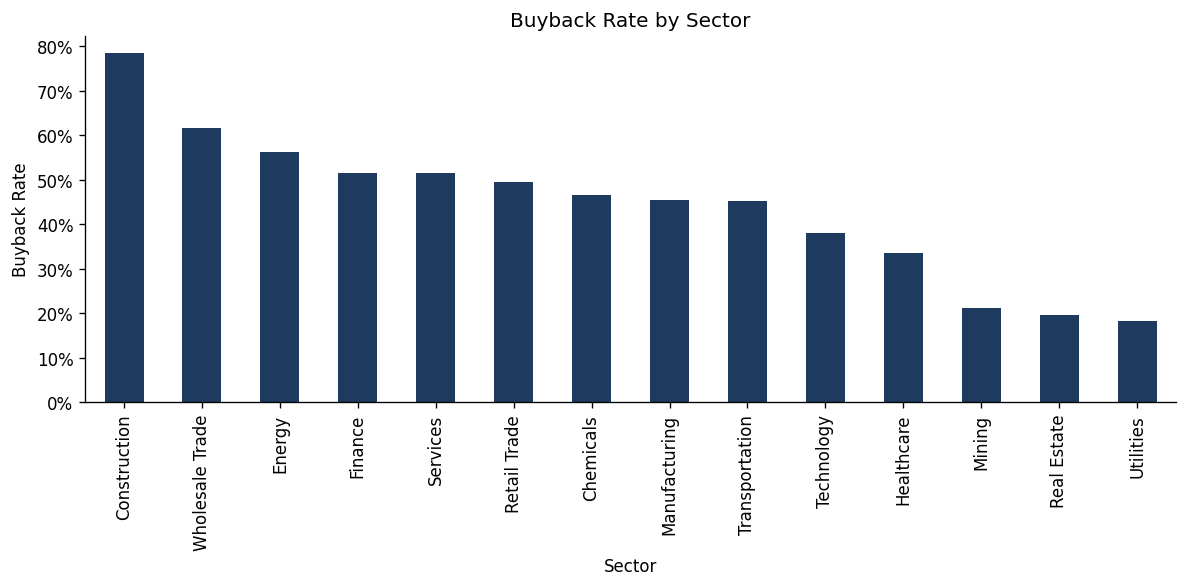

In [14]:
sector_rates = (df.groupby('sector')['buyback_next_quarter'].mean().sort_values(ascending=False))

ax = sector_rates.plot(kind="bar", figsize=(10, 5), color="#1E3A5F")

plt.title("Buyback Rate by Sector")
plt.xlabel("Sector")
plt.ylabel("Buyback Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

plt.tight_layout()
plt.show()

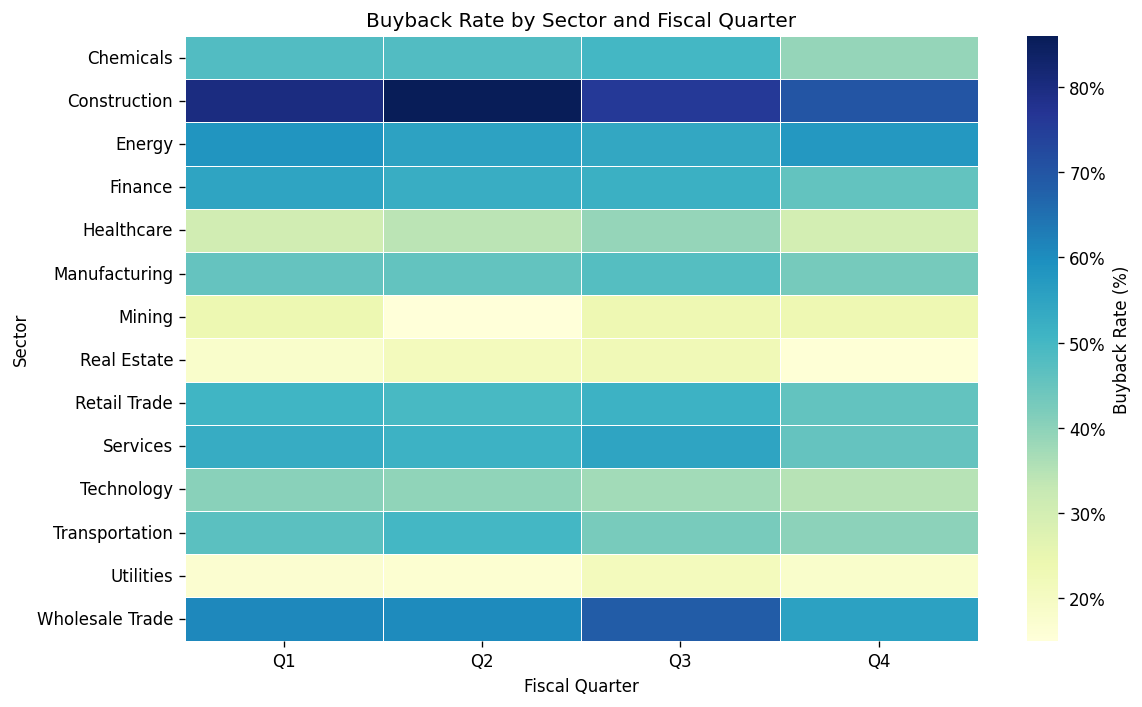

In [15]:
heatmap_data = (df.groupby(["sector", "fiscal_period"])["buyback_next_quarter"].mean().reset_index()
                .pivot(index="sector", columns="fiscal_period", values="buyback_next_quarter")
                .reindex(columns=["Q1", "Q2", "Q3", "Q4"])
)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.3)

plt.title("Buyback Rate by Sector and Fiscal Quarter")
plt.xlabel("Fiscal Quarter")
plt.ylabel("Sector")

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
cbar.set_label("Buyback Rate (%)")

plt.tight_layout()
plt.show()

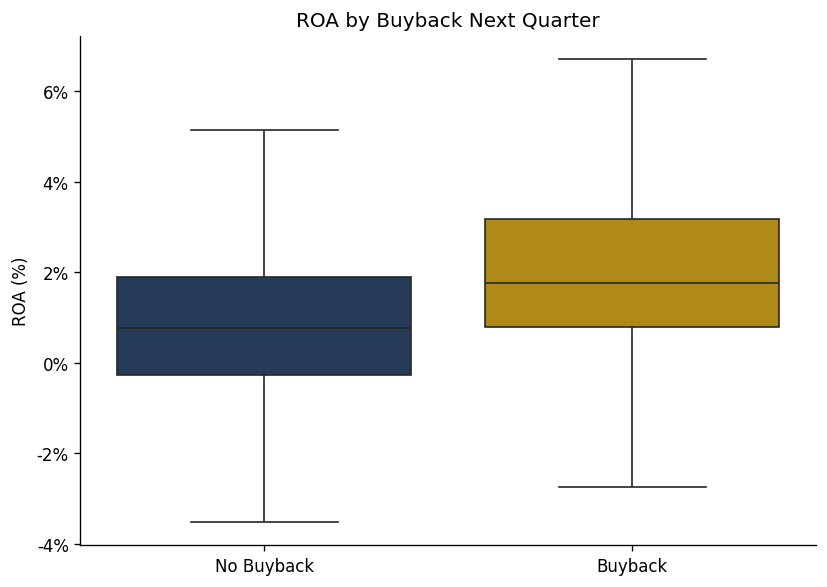

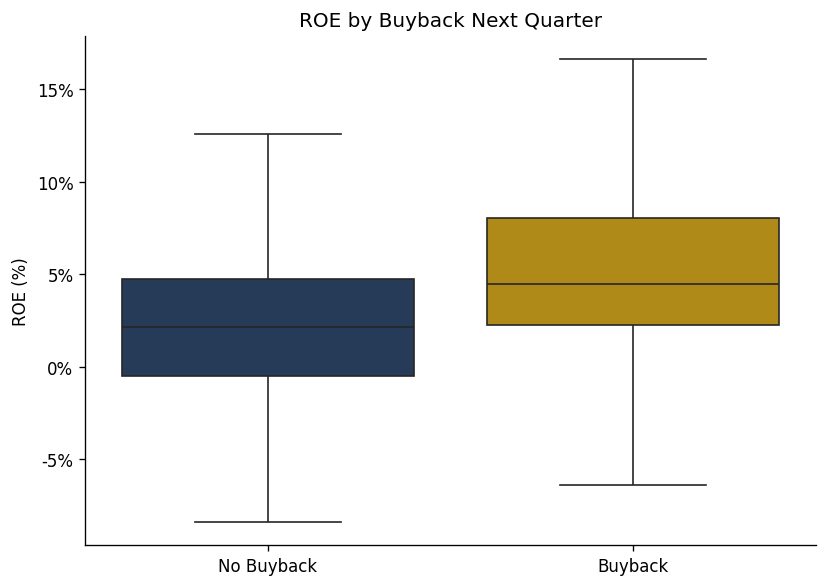

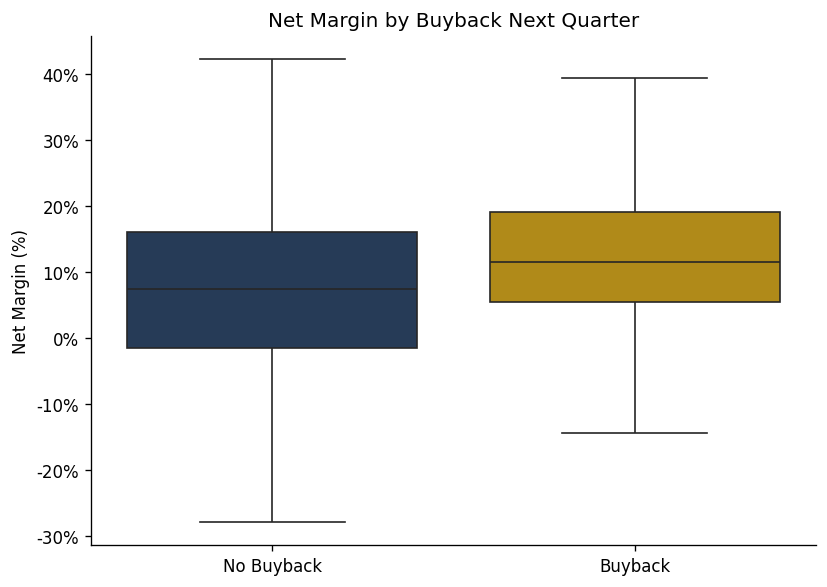

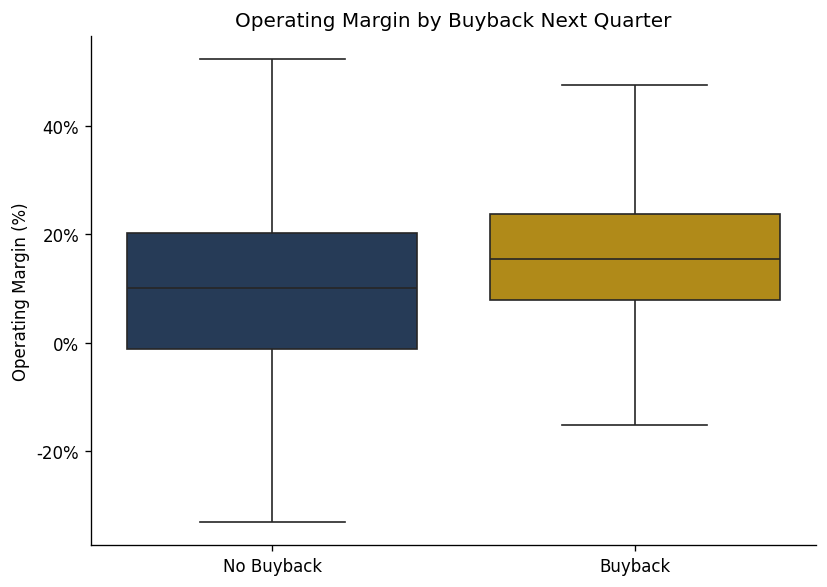

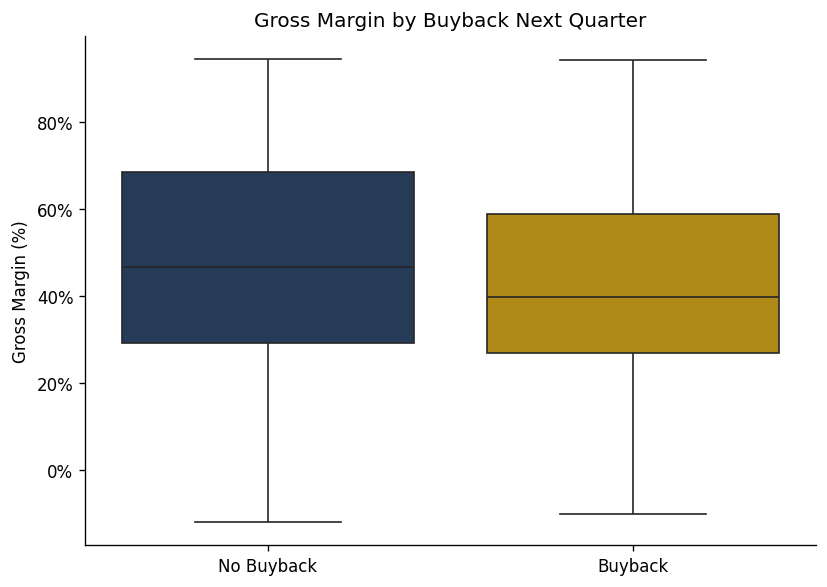

In [16]:
# Heavily assisted by ChatGPT

pretty_names = {
    "ROA_q": "ROA",
    "ROE_q": "ROE",
    "net_margin_q": "Net Margin",
    "operating_margin_q": "Operating Margin",
    "gross_margin_q": "Gross Margin"
}

profit_vars = [
    "ROA_q",
    "ROE_q",
    "net_margin_q",
    "operating_margin_q",
    "gross_margin_q"
]

profit_vars = [c for c in profit_vars if c in df.columns]

for col in profit_vars:
    plot_df = df[[col, "buyback_next_quarter"]].copy()

    # Clean for plotting
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
    plot_df["buyback_next_quarter"] = pd.to_numeric(
        plot_df["buyback_next_quarter"], errors="coerce"
    )
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    # Convert target to strings so palette keys match exactly
    plot_df["buyback_next_quarter"] = plot_df["buyback_next_quarter"].astype(int).astype(str)

    # Convert to percent for nicer axes
    plot_df[col] = plot_df[col] * 100

    # Clip just for plotting
    low = plot_df[col].quantile(0.01)
    high = plot_df[col].quantile(0.99)
    plot_df = plot_df[(plot_df[col] >= low) & (plot_df[col] <= high)]

    plt.figure(figsize=(7, 5))
    ax = sns.boxplot(
        data=plot_df,
        x="buyback_next_quarter",
        y=col,
        order=["0", "1"],
        showfliers=False,
        palette={"0": "#1E3A5F", "1": "#C99700"}
    )

    plt.title(f"{pretty_names[col]} by Buyback Next Quarter")
    plt.xlabel("")
    plt.ylabel(f"{pretty_names[col]} (%)")
    ax.set_xticklabels(["No Buyback", "Buyback"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))

    plt.tight_layout()
    plt.show()

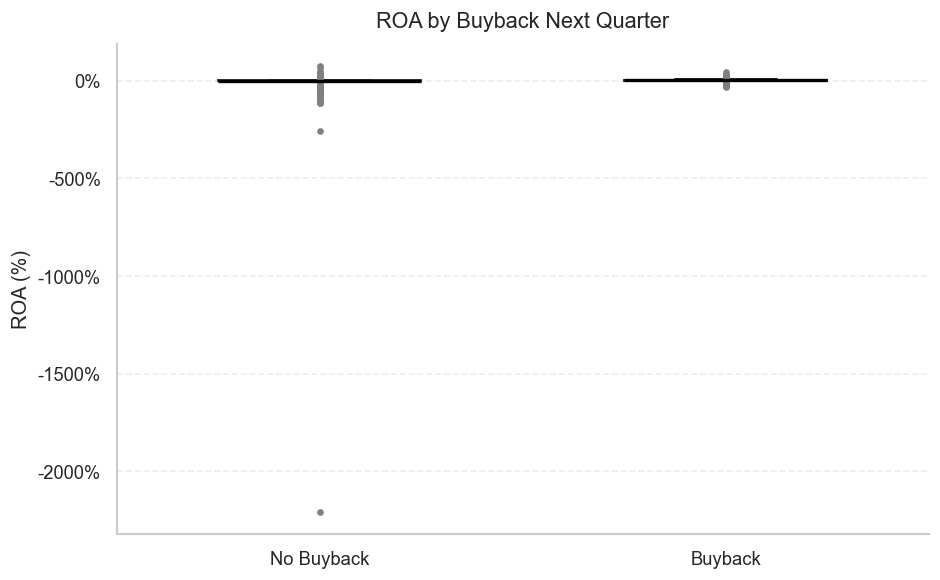

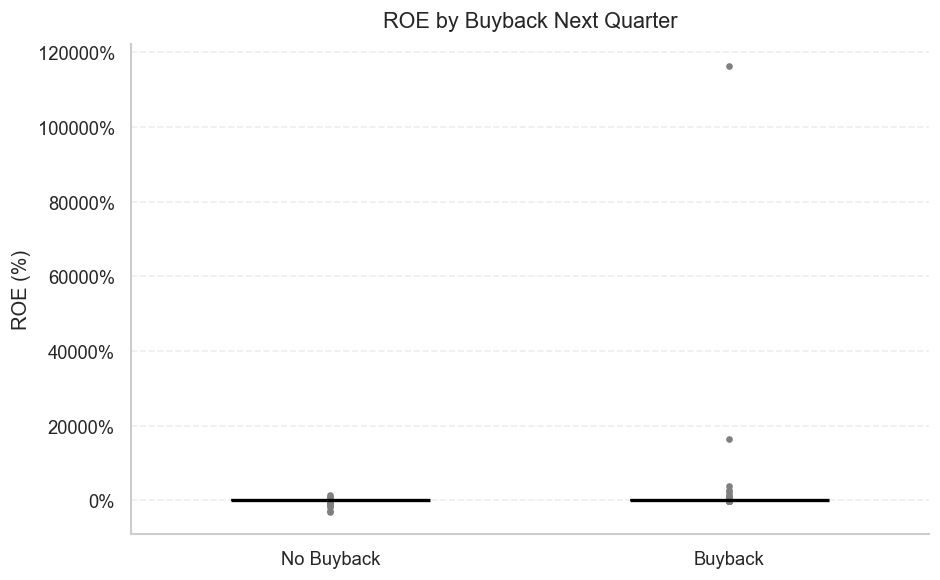

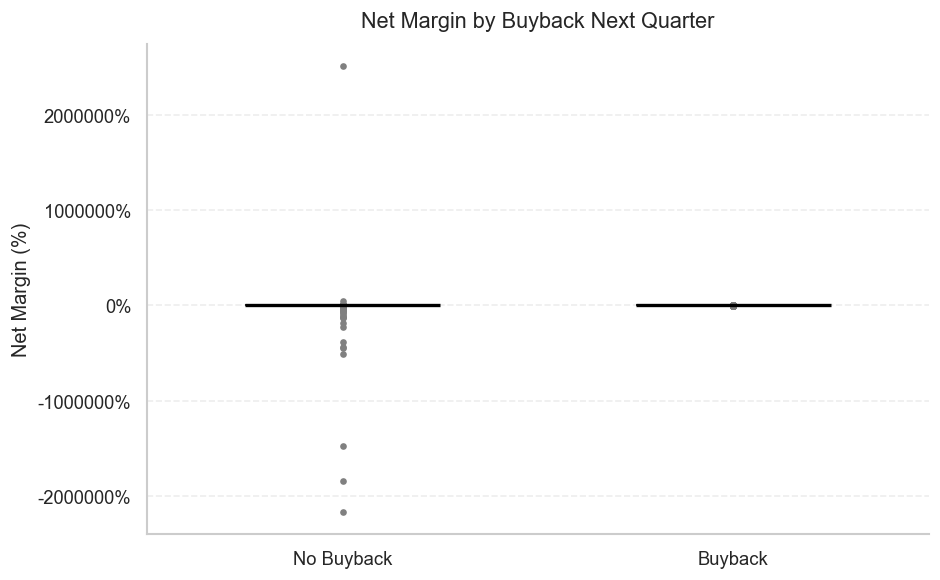

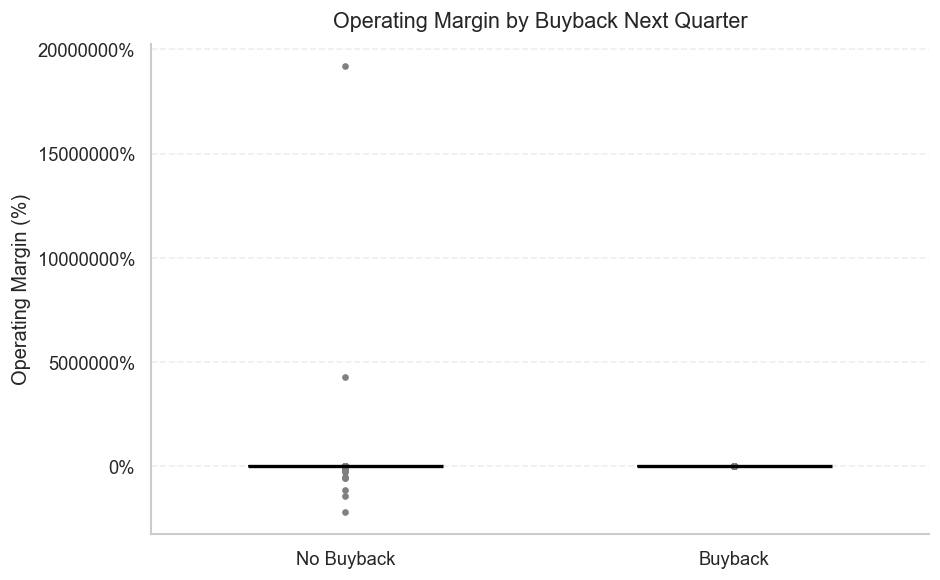

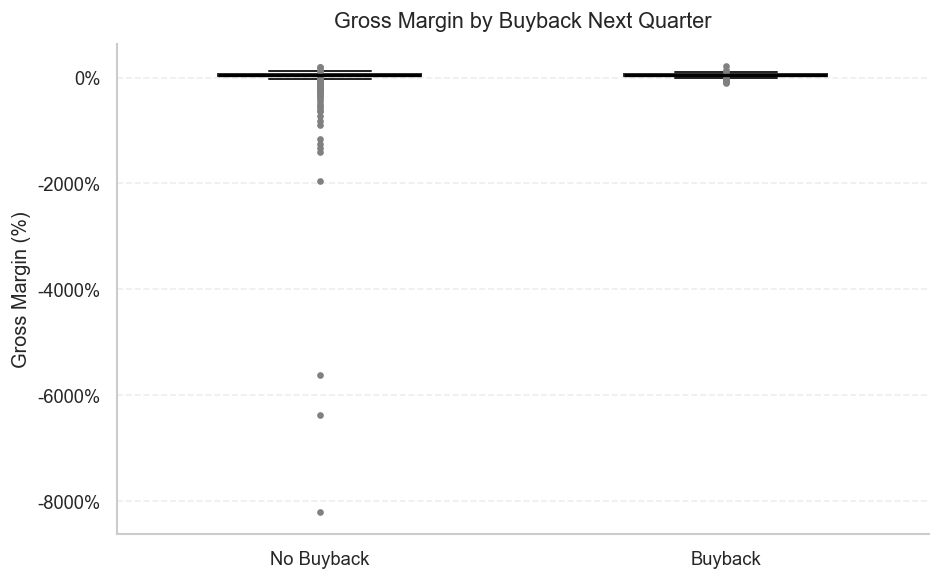

In [17]:
# This visualization was purely made by ChatGPT

sns.set_theme(style="whitegrid")

profit_vars = [
    "ROA_q",
    "ROE_q",
    "net_margin_q",
    "operating_margin_q",
    "gross_margin_q"
]

profit_vars = [c for c in profit_vars if c in df.columns]

pretty_names = {
    "ROA_q": "ROA",
    "ROE_q": "ROE",
    "net_margin_q": "Net Margin",
    "operating_margin_q": "Operating Margin",
    "gross_margin_q": "Gross Margin"
}

for col in profit_vars:
    plot_df = df[[col, "buyback_next_quarter"]].copy()

    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    # make target strings so palette/order match exactly
    plot_df["buyback_next_quarter"] = (
        pd.to_numeric(plot_df["buyback_next_quarter"], errors="coerce")
        .astype(int)
        .astype(str)
    )

    # convert to percent for nicer axes
    plot_df[col] = plot_df[col] * 100

    plt.figure(figsize=(8, 5))

    ax = sns.boxplot(
        data=plot_df,
        x="buyback_next_quarter",
        y=col,
        order=["0", "1"],
        palette={"0": "#1E3A5F", "1": "#C99700"},
        showfliers=True,
        width=0.5,
        linewidth=1.2,
        boxprops=dict(alpha=0.9),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="gray",
            markeredgecolor="gray",
            alpha=1
        )
    )

    ax.set_title(f"{pretty_names[col]} by Buyback Next Quarter", fontsize=13, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(f"{pretty_names[col]} (%)")
    ax.set_xticklabels(["No Buyback", "Buyback"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    sns.despine()
    plt.tight_layout()
    plt.show()

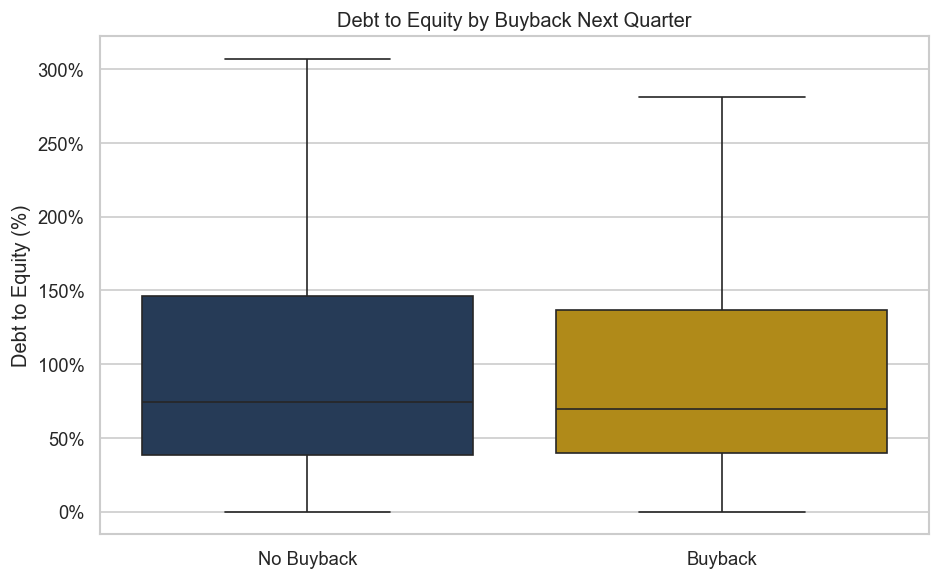

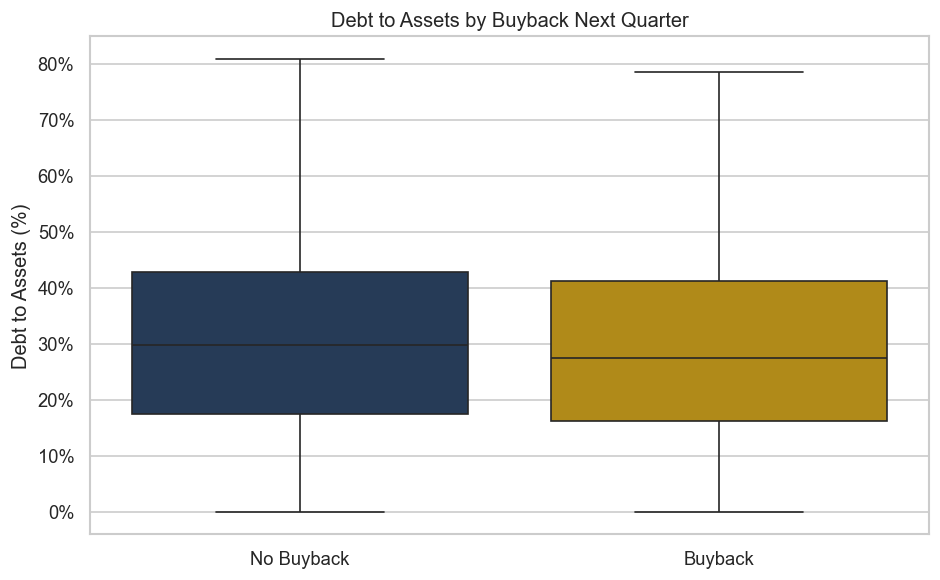

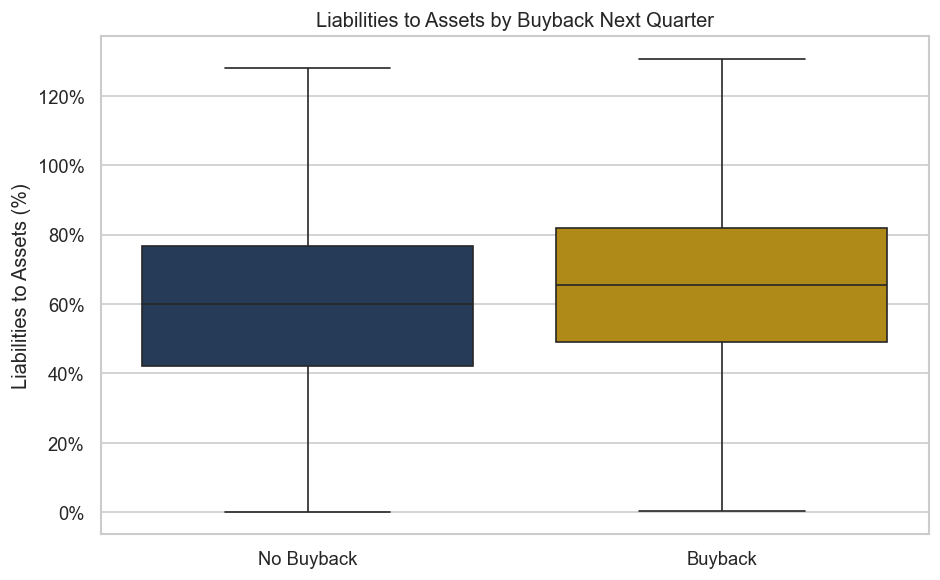

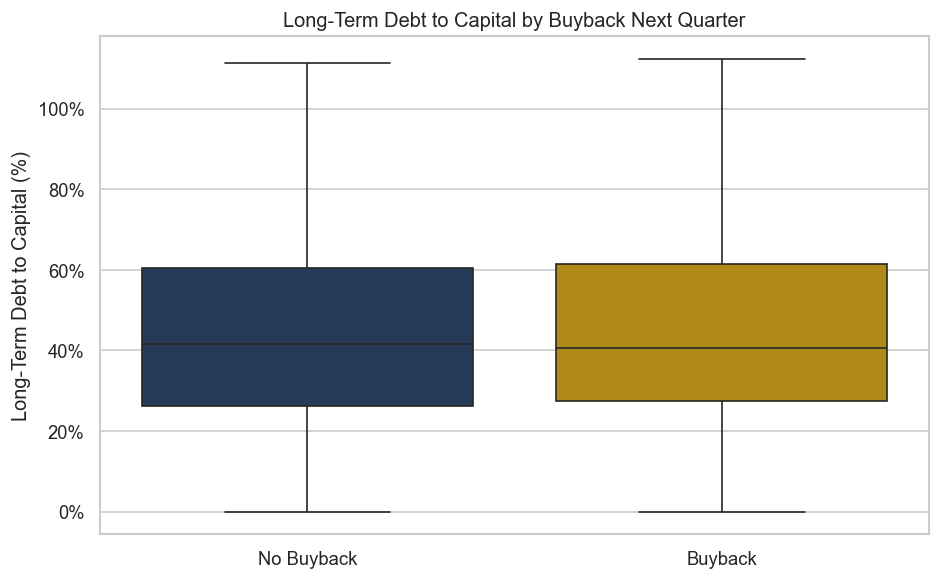

In [18]:
sns.set_theme(style="whitegrid")

leverage_vars = [
    "debt_to_equity_q",
    "debt_to_assets_q",
    "liabilities_to_assets_q",
    "long_term_debt_to_capital_q"
]

pretty_names = {
    "debt_to_equity_q": "Debt to Equity",
    "debt_to_assets_q": "Debt to Assets",
    "liabilities_to_assets_q": "Liabilities to Assets",
    "long_term_debt_to_capital_q": "Long-Term Debt to Capital"
}

leverage_vars = [c for c in leverage_vars if c in df.columns]

for col in leverage_vars:
    plot_df = df[[col, "buyback_next_quarter"]].copy()
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
    plot_df["buyback_label"] = pd.to_numeric(
        plot_df["buyback_next_quarter"], errors="coerce"
    ).map({0: "No Buyback", 1: "Buyback"})
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    plot_df[col] = plot_df[col] * 100

    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(
        data=plot_df,
        x="buyback_label",
        y=col,
        order=["No Buyback", "Buyback"],
        palette=["#1E3A5F", "#C99700"],
        showfliers=False
    )

    plt.title(f"{pretty_names[col]} by Buyback Next Quarter")
    plt.xlabel("")
    plt.ylabel(f"{pretty_names[col]} (%)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    plt.tight_layout()
    plt.show()

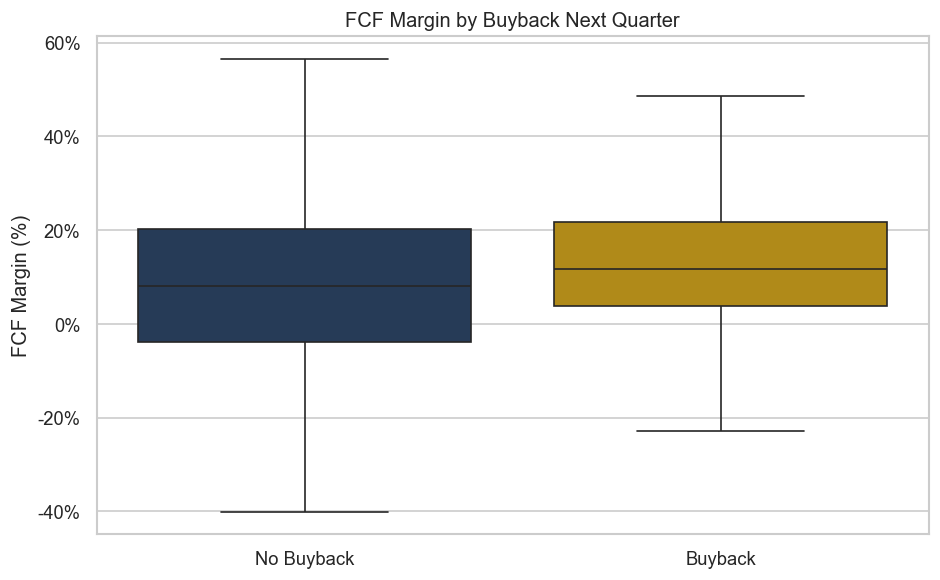

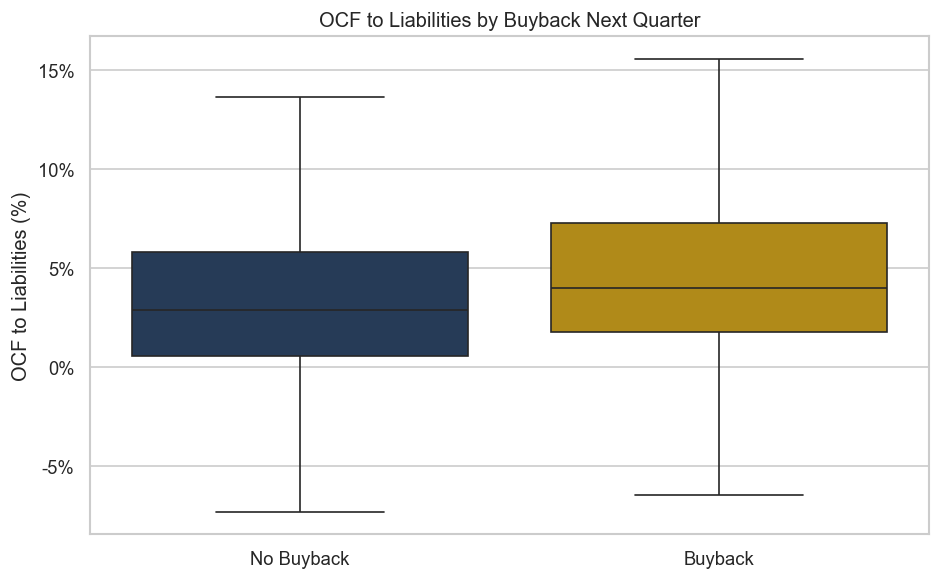

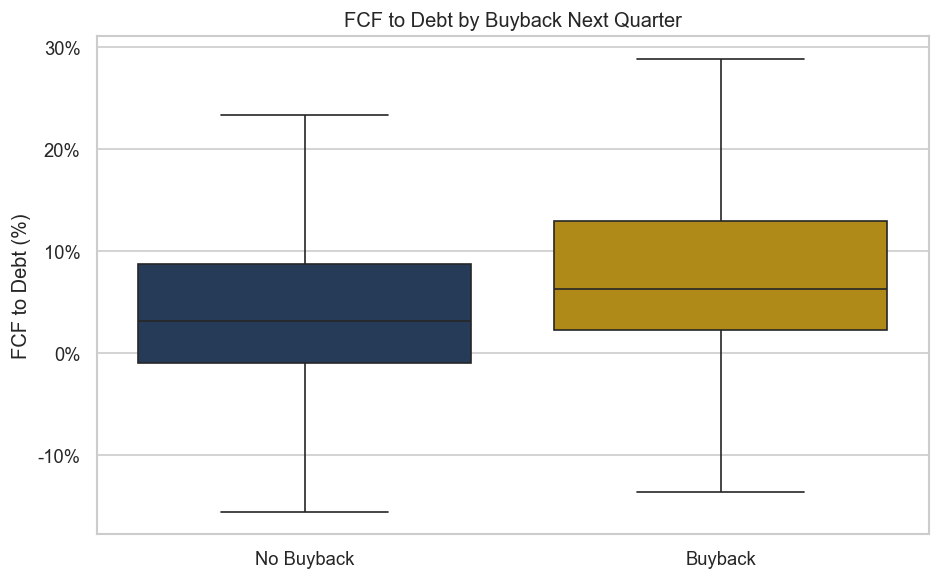

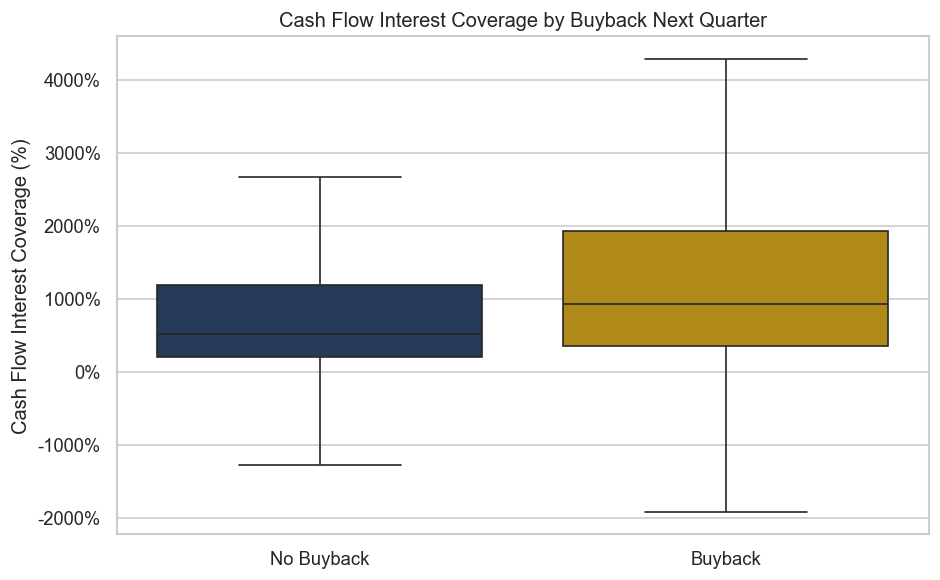

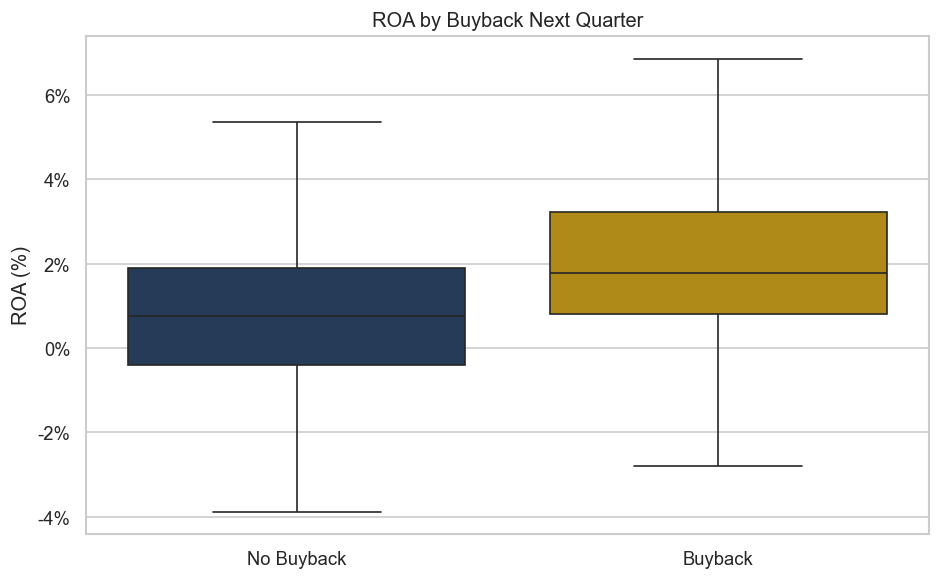

In [19]:
cashflow_vars = [
    "FCF_margin_q",
    "OCF_to_liabilities_q",
    "FCF_to_debt_q",
    "cash_flow_interest_coverage_q",
    "ROA_q"
]

pretty_names = {
    "FCF_margin_q": "FCF Margin",
    "OCF_to_liabilities_q": "OCF to Liabilities",
    "FCF_to_debt_q": "FCF to Debt",
    "cash_flow_interest_coverage_q": "Cash Flow Interest Coverage",
    "ROA_q": "ROA"
}

cashflow_vars = [c for c in cashflow_vars if c in df.columns]

for col in cashflow_vars:
    plot_df = df[[col, "buyback_next_quarter"]].copy()
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")
    plot_df["buyback_label"] = pd.to_numeric(
        plot_df["buyback_next_quarter"], errors="coerce"
    ).map({0: "No Buyback", 1: "Buyback"})
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    plot_df[col] = plot_df[col] * 100

    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(
        data=plot_df,
        x="buyback_label",
        y=col,
        order=["No Buyback", "Buyback"],
        palette=["#1E3A5F", "#C99700"],
        showfliers=False
    )

    plt.title(f"{pretty_names[col]} by Buyback Next Quarter")
    plt.xlabel("")
    plt.ylabel(f"{pretty_names[col]} (%)")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
    plt.tight_layout()
    plt.show()

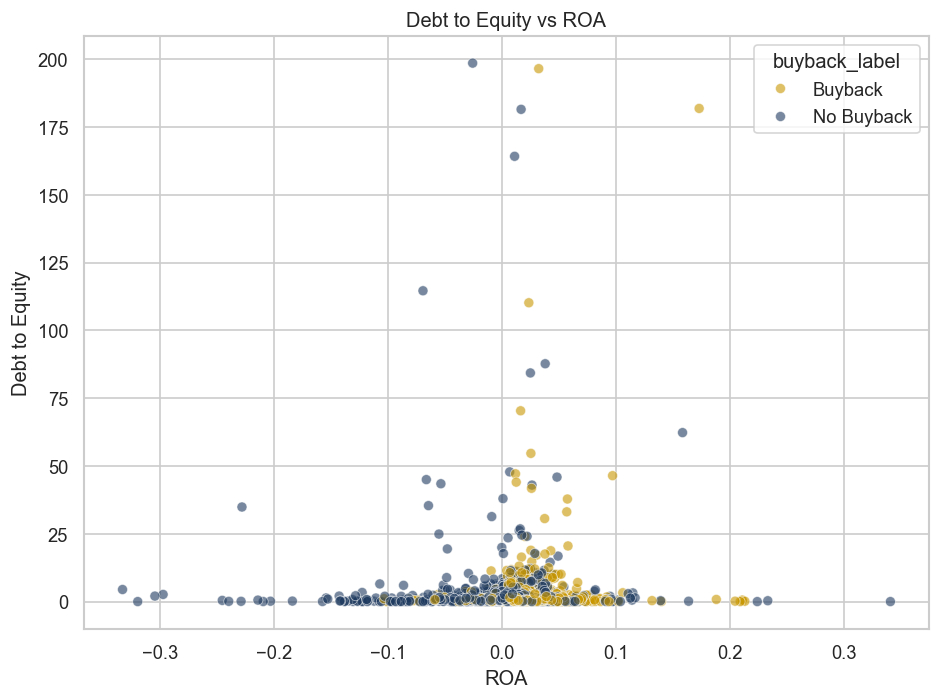

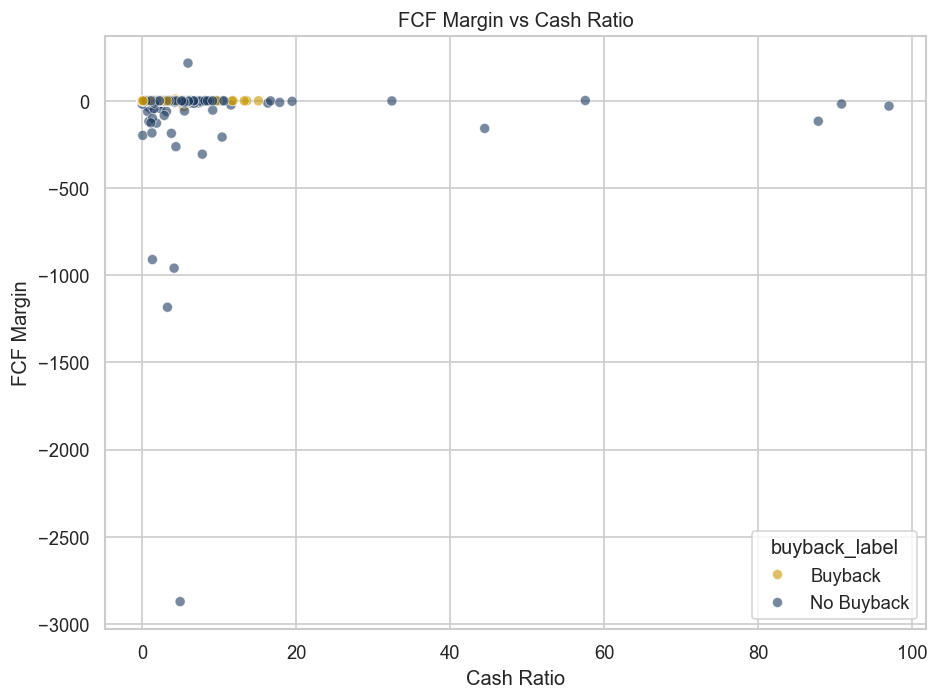

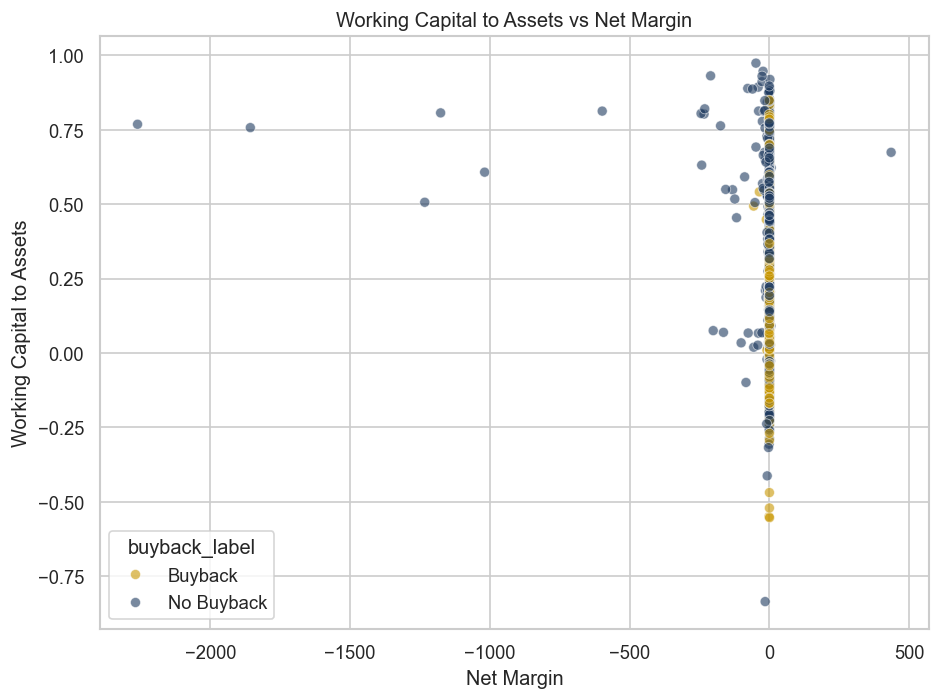

In [20]:
scatter_pairs = [
    ("ROA_q", "debt_to_equity_q"),
    ("cash_ratio_q", "FCF_margin_q"),
    ("net_margin_q", "working_capital_to_assets_q")
]

pretty_names = {
    "ROA_q": "ROA",
    "debt_to_equity_q": "Debt to Equity",
    "cash_ratio_q": "Cash Ratio",
    "FCF_margin_q": "FCF Margin",
    "net_margin_q": "Net Margin",
    "working_capital_to_assets_q": "Working Capital to Assets"
}

scatter_pairs = [(x, y) for x, y in scatter_pairs if x in df.columns and y in df.columns]

sample_df = df.sample(min(len(df), 5000), random_state=1).copy()

for x_col, y_col in scatter_pairs:
    plot_df = sample_df[[x_col, y_col, "buyback_next_quarter"]].copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df["buyback_label"] = pd.to_numeric(
        plot_df["buyback_next_quarter"], errors="coerce"
    ).map({0: "No Buyback", 1: "Buyback"})
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        hue="buyback_label",
        palette={"No Buyback": "#1E3A5F", "Buyback": "#C99700"},
        alpha=0.6
    )

    plt.title(f"{pretty_names[y_col]} vs {pretty_names[x_col]}")
    plt.xlabel(pretty_names[x_col])
    plt.ylabel(pretty_names[y_col])
    plt.tight_layout()
    plt.show()

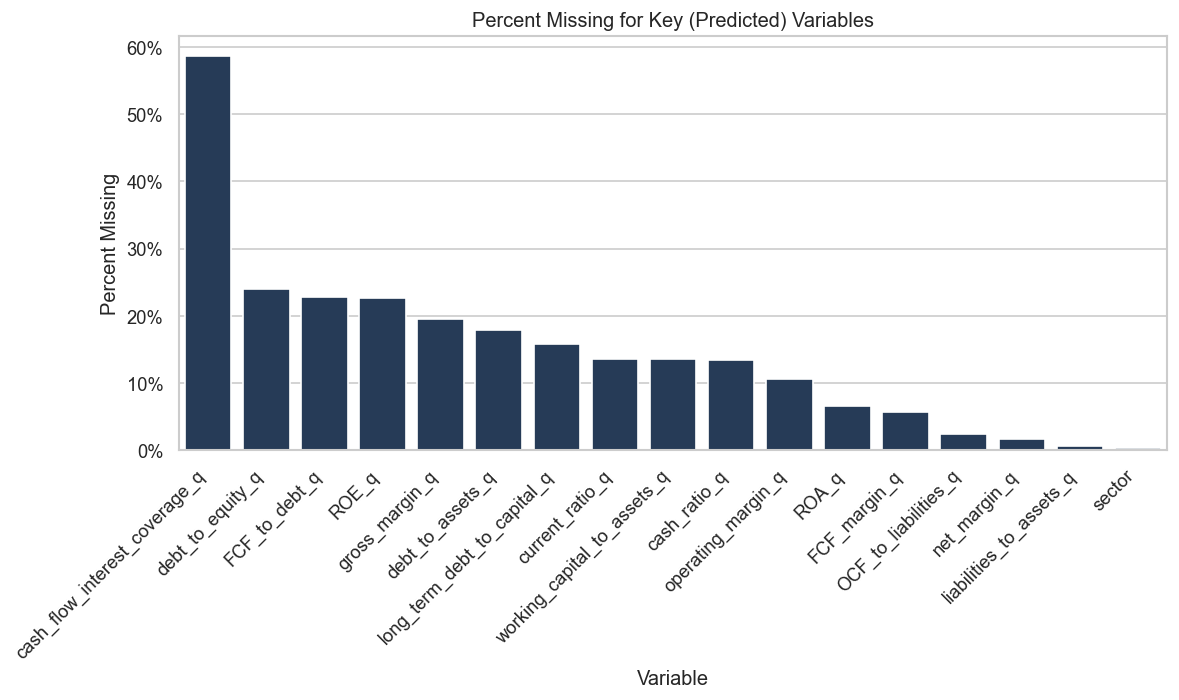

In [21]:
important_vars = [
    "ROA_q",
    "ROE_q",
    "net_margin_q",
    "operating_margin_q",
    "gross_margin_q",
    "cash_ratio_q",
    "current_ratio_q",
    "working_capital_to_assets_q",
    "debt_to_equity_q",
    "debt_to_assets_q",
    "liabilities_to_assets_q",
    "long_term_debt_to_capital_q",
    "FCF_margin_q",
    "OCF_to_liabilities_q",
    "FCF_to_debt_q",
    "cash_flow_interest_coverage_q",
    "sector"
]

important_vars = [c for c in important_vars if c in df.columns]

missing_pct = (
    df[important_vars]
    .isna()
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=missing_pct.index, y=missing_pct.values, color="#1E3A5F")
plt.title("Percent Missing for Key (Predicted) Variables")
plt.xlabel("Variable")
plt.ylabel("Percent Missing")
plt.xticks(rotation=45, ha="right")
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.tight_layout()
plt.show()


Market Cap Summary by Buyback Outcome:


,buyback_group,count,average_market_cap,median_market_cap,std_market_cap,Bottom25pct_market_cap,Top25pct_market_cap
0,Buyback Next Quarter,7304,63.71,17.65,220.78,7.47,46.42
1,No Buyback Next Quarter,9637,36.46,12.10,124.89,4.53,30.40


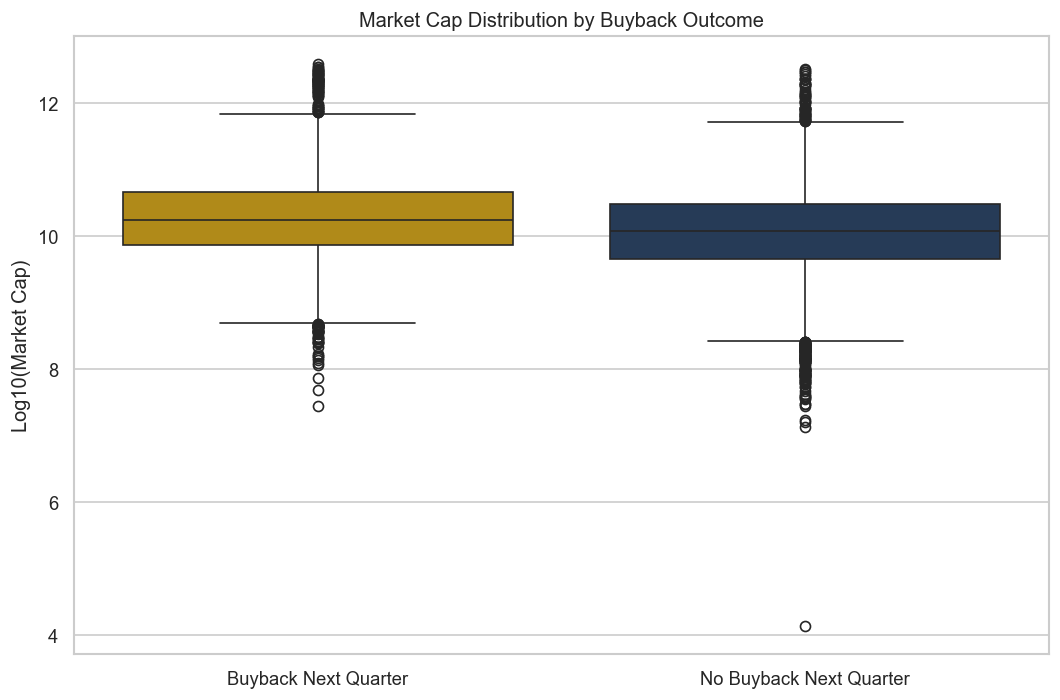

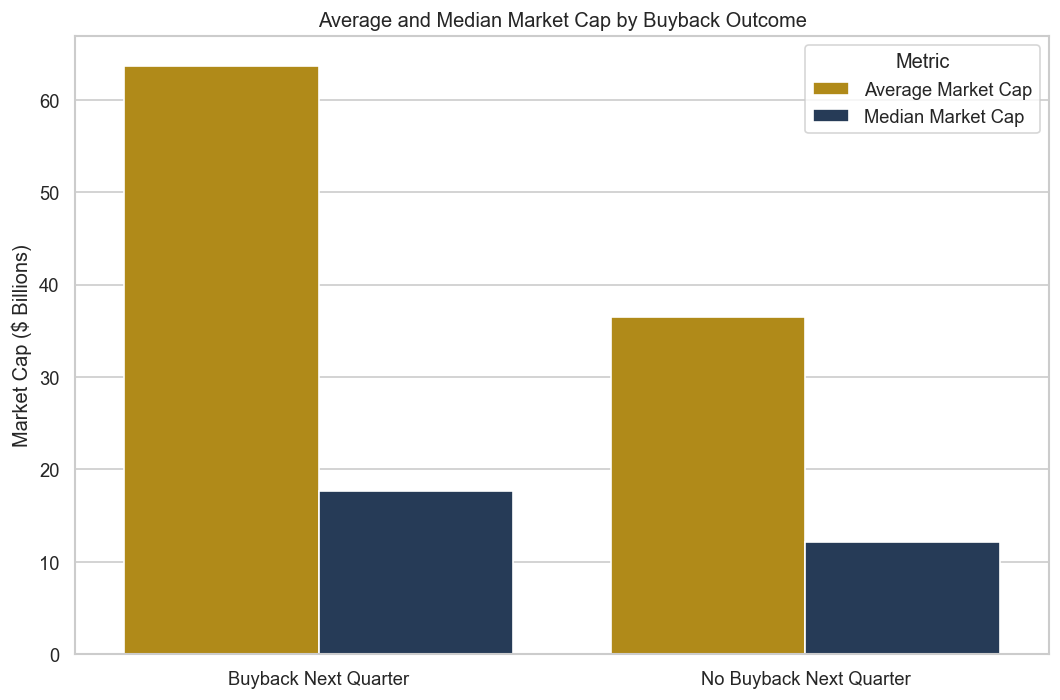

In [22]:
# EDA: Market Cap Distribution by Buyback Outcome

eda_market_cap = df.copy()

# Set column names
target_col = 'buyback_next_quarter'
market_cap_col = 'basic_market_cap_q'


# Keep only rows with valid market cap and target values
eda_market_cap = eda_market_cap[[target_col, market_cap_col]].dropna()

# Remove zero or negative market cap values because log transformation cannot handle them (just in case it blows up)
eda_market_cap = eda_market_cap[eda_market_cap[market_cap_col] > 0].copy()


# Convert market cap to billions for easier interpretation
eda_market_cap['market_cap_billions'] = eda_market_cap[market_cap_col] / 1000000000

# Log market cap for the distribution graph
eda_market_cap['log_market_cap'] = np.log10(eda_market_cap[market_cap_col])


# Create readable labels
eda_market_cap['buyback_group'] = eda_market_cap[target_col].map({
    0: 'No Buyback Next Quarter',
    1: 'Buyback Next Quarter'
})


# Summary table: Market cap by buyback outcome

market_cap_summary = (
    eda_market_cap
    .groupby('buyback_group')['market_cap_billions']
    .agg(
        count='count',
        average_market_cap='mean',
        median_market_cap='median',
        std_market_cap='std',
        Bottom25pct_market_cap=lambda x: x.quantile(0.25),
        Top25pct_market_cap=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# Round for cleaner display
market_cap_summary_rounded = market_cap_summary.copy()

cols_to_round = [
    'average_market_cap',
    'median_market_cap',
    'std_market_cap',
    'Bottom25pct_market_cap',
    'Top25pct_market_cap'
]

market_cap_summary_rounded[cols_to_round] = market_cap_summary_rounded[cols_to_round].round(2)

print("\nMarket Cap Summary by Buyback Outcome:")
display(market_cap_summary_rounded)


# Boxplot: Distribution of market cap by buyback outcome

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=eda_market_cap,
    x='buyback_group',
    y='log_market_cap',
    palette=['#C99700','#1E3A5F']
)

plt.title('Market Cap Distribution by Buyback Outcome')
plt.xlabel('')
plt.ylabel('Log10(Market Cap)')

plt.tight_layout()
plt.show()

# Bar chart: Average and median market cap by buyback outcome

market_cap_bar = market_cap_summary_rounded.melt(
    id_vars='buyback_group',
    value_vars=['average_market_cap', 'median_market_cap'],
    var_name='metric',
    value_name='market_cap_billions'
)

market_cap_bar['metric'] = market_cap_bar['metric'].map({
    'average_market_cap': 'Average Market Cap',
    'median_market_cap': 'Median Market Cap'
})

plt.figure(figsize=(9, 6))

sns.barplot(
    data=market_cap_bar,
    x='buyback_group',
    y='market_cap_billions',
    hue='metric',
    palette=['#C99700','#1E3A5F']
)

plt.title('Average and Median Market Cap by Buyback Outcome')
plt.xlabel('')
plt.ylabel('Market Cap ($ Billions)')
plt.legend(title='Metric')

plt.tight_layout()
plt.show()

In [23]:
# Interpretation of log10(market_cap):

# log10(market_cap) = 9   means market cap is about $1 billion
# log10(market_cap) = 10  means market cap is about $10 billion
# log10(market_cap) = 11  means market cap is about $100 billion
# log10(market_cap) = 12  means market cap is about $1 trillion

In [24]:
share_count_change = df[['share_count_change_pct_q']]
share_count_change.describe()

,share_count_change_pct_q
count,1.610200e+04
mean,1.773690e+04
std,2.166493e+06
min,-9.656793e+01
25%,-5.503821e-01
50%,8.697190e-03
75%,2.530438e-01
max,2.747016e+08
